In [26]:
import pandas as pd
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.patches import Patch, ConnectionPatch
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from matplotlib import gridspec
from scipy.spatial import Voronoi
from scipy.spatial import cKDTree
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns
import itertools

import umap
from umap.umap_ import nearest_neighbors
from sklearn.preprocessing import StandardScaler

import hdbscan

from sklearn.metrics import silhouette_score

In [14]:
sns.set_theme(style="ticks", font_scale=1.6)
CALL_TYPE_COLORS = {'alarm': (0.2823529411764706, 0.47058823529411764, 0.8156862745098039), 
                    'contact': (0.9333333333333333, 0.5215686274509804, 0.2901960784313726), 
                    'departure': (0.41568627450980394, 0.8, 0.39215686274509803), 
                    'distance': (0.8392156862745098, 0.37254901960784315, 0.37254901960784315), 
                    'recruitment': (0.5843137254901961, 0.4235294117647059, 0.7058823529411765), 
                    'triumph': (0.5490196078431373, 0.3803921568627451, 0.23529411764705882)}
DOT_SIZE = 10
ALPHA = .6

## Functions

In [9]:
def display_nearest_neighbours(nn_graph, df, n_examples=5, n_neighbors=15):
    fig, axs = plt.subplots(nrows=n_examples, ncols=n_neighbors, figsize=(n_neighbors, n_examples))

    for i in range(n_examples):
        for j in range(n_neighbors):
            axs[i, j].matshow(df.iloc[nn_graph[0][i][j]]["log_padded_spectrogram"], origin="lower", cmap="binary", aspect="auto")
            axs[i, j].axis("off")
    plt.tight_layout()
    plt.show()

In [25]:
def scatter_projections(
    syllables=None,
    projection=None,
    labels=None,
    ax=None,
    figsize=(10, 10),
    alpha=0.1,
    s=1,
    color="k",
    color_palette="tab20",
    categorical_labels=True,
    show_legend=True,
    tick_pos="bottom",
    tick_size=16,
    cbar_orientation="vertical",
    log_x=False,
    log_y=False,
    grey_unlabelled=True,
    fig=None,
    colornorm=False,
    rasterized=True,
    equalize_axes=True,
    print_lab_dict=False,  # prints color scheme
):
    """ 
    creates a scatterplot of syllables using some projection
    From Sainburg et al. 2020: https://github.com/timsainb/avgn_paper/blob/V2/avgn/visualization/projections.py
    """
    if projection is None and syllables is None:
            raise ValueError("Either syllables or projections must be passed")

    # color labels
    if labels is not None:
        if categorical_labels:
            if (color_palette == "tab20") & (len(np.unique(labels)) < 20):
                pal = sns.color_palette(color_palette, n_colors=20)
                pal = np.array(pal)[
                    np.linspace(0, 19, len(np.unique(labels))).astype("int")
                ]
            else:
                pal = sns.color_palette(color_palette, n_colors=len(np.unique(labels)))
            lab_dict = {lab: pal[i] for i, lab in enumerate(np.unique(labels))}
            if grey_unlabelled:
                if -1 in lab_dict.keys():
                    lab_dict[-1] = [0.95, 0.95, 0.95, 1.0]
                if print_lab_dict:
                    print(lab_dict)
            colors = np.array([lab_dict[i] for i in labels])
    else:
        colors = color

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if colornorm:
        norm = LogNorm()
    else:
        norm = None

    if categorical_labels or labels is None:
        ax.scatter(
            projection[:, 0],
            projection[:, 1],
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            color=colors,
            norm=norm,
        )

    else:
        cmin = np.quantile(labels, 0.01)
        cmax = np.quantile(labels, 0.99)
        sct = ax.scatter(
            projection[:, 0],
            projection[:, 1],
            vmin=cmin,
            vmax=cmax,
            cmap=plt.get_cmap(color_palette),
            rasterized=rasterized,
            alpha=alpha,
            s=s,
            c=labels,
        )

    if log_x:
        ax.set_xscale("log")
    if log_y:
        ax.set_yscale("log")

    if labels is not None:
        if categorical_labels == True:
            legend_elements = [
                Line2D([0], [0], marker="o", color=value, label=key)
                for key, value in lab_dict.items()
            ]
        if show_legend:
            if not categorical_labels:
                if cbar_orientation == "horizontal":
                    axins1 = inset_axes(
                        ax,
                        width="50%",  # width = 50% of parent_bbox width
                        height="5%",  # height : 5%
                        loc="upper left",
                    )
                    # cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation

                else:
                    axins1 = inset_axes(
                        ax,
                        width="5%",  # width = 50% of parent_bbox width
                        height="50%",  # height : 5%
                        loc="lower right",
                    )
                cbar = fig.colorbar(sct, cax=axins1, orientation=cbar_orientation)
                cbar.ax.tick_params(labelsize=tick_size)
                axins1.xaxis.set_ticks_position(tick_pos)
            else:
                ax.legend(handles=legend_elements)
    if equalize_axes:
        ax.axis("equal")
    return ax

def scatter_spec(
    z,
    specs,
    column_size=10,
    pal_color="hls",
    matshow_kwargs={"cmap": plt.cm.Greys},
    scatter_kwargs={"alpha": 0.5, "s": 1},
    line_kwargs={"lw": 1, "ls": "dashed", "alpha": 1},
    color_points=False,
    figsize=(10, 10),
    range_pad=0.1,
    x_range=None,
    y_range=None,
    enlarge_points=0,
    draw_lines=True,
    n_subset=-1,
    ax=None,
    show_scatter=True,
    border_line_width=1,
    img_origin="lower",
):
    n_columns = column_size * 4 - 4
    pal = sns.color_palette(pal_color, n_colors=n_columns)

    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(column_size, column_size)

    # Determine plotting range
    if x_range is None and y_range is None:
        z_arr = np.vstack(z)
        x_sorted = np.sort(z_arr[:, 0])
        y_sorted = np.sort(z_arr[:, 1])
        xmin, xmax = x_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        ymin, ymax = y_sorted[[int(len(z_arr) * 0.01), int(len(z_arr) * 0.99)]]
        xmin -= (xmax - xmin) * range_pad
        xmax += (xmax - xmin) * range_pad
        ymin -= (ymax - ymin) * range_pad
        ymax += (ymax - ymin) * range_pad
    else:
        xmin, xmax = x_range
        ymin, ymax = y_range

    x_block = (xmax - xmin) / column_size
    y_block = (ymax - ymin) / column_size

    # Filter to points within range
    z = np.array(z)
    mask = (z[:, 0] > xmin) & (z[:, 1] > ymin) & (z[:, 0] < xmax) & (z[:, 1] < ymax)

    if "labels" in scatter_kwargs:
        scatter_kwargs["labels"] = np.array(scatter_kwargs["labels"])[mask]
    specs = np.array(specs)[mask]
    z = z[mask]

    # Respect n_subset only when positive
    if n_subset is not None and n_subset > 0:
        z = z[:n_subset]
        specs = specs[:n_subset]
        if "labels" in scatter_kwargs:
            scatter_kwargs["labels"] = scatter_kwargs["labels"][:n_subset]

    # Prepare the main axis
    main_ax = fig.add_subplot(gs[1 : column_size - 1, 1 : column_size - 1])
    if show_scatter and len(z) > 0:
        scatter_projections(projection=z, ax=main_ax, fig=fig, **scatter_kwargs)

    # Build the ring of small axes
    axs = {}
    for column in range(n_columns):
        # decide row/col on the ring
        if column < column_size:
            row = 0
            col = column
        elif (column >= column_size) and (column < (column_size * 2) - 1):
            row = column - column_size + 1
            col = column_size - 1
        elif (column >= ((column_size * 2) - 1)) and (column < (column_size * 3 - 2)):
            row = column_size - 1
            col = column_size - 3 - (column - column_size * 2)
        else:
            row = n_columns - column
            col = 0

        axs[column] = {"ax": fig.add_subplot(gs[row, col]), "col": col, "row": row}

        # geometric center for this small axis (in data coords)
        xpos = xmin + x_block * col + x_block / 2
        ypos = ymax - y_block * row - y_block / 2
        axs[column]["xpos"] = xpos
        axs[column]["ypos"] = ypos

    main_ax.set_xlim([xmin, xmax])
    main_ax.set_ylim([ymin, ymax])

    if len(z) == 0:
        gs.update(wspace=0, hspace=0)
        return fig  # nothing to connect

    # Voronoi over the ring cell centers, then assign each z-point to nearest center
    points = np.array([[axs[i]["xpos"], axs[i]["ypos"]] for i in axs.keys()])
    voronoi_kdtree = cKDTree(points)
    # index of closest cell center for each z point
    _, point_regions = voronoi_kdtree.query(z)

    # Track which z points have been used so we don't reuse the same one
    used = np.zeros(len(z), dtype=bool)
    lines_list = []

    # Loop through cells on the ring and pick a representative z point
    for key in axs.keys():
        ax_small = axs[key]["ax"]

        # pick a z point assigned to this region that hasn't been used
        in_region = np.where((point_regions == key) & (~used))[0]

        if in_region.size:
            chosen_point = np.random.choice(in_region)
        else:
            # fallback: choose nearest unused to the cell center
            center = np.array([axs[key]["xpos"], axs[key]["ypos"]])
            avail = np.where(~used)[0]
            dists = np.linalg.norm(z[avail] - center, axis=1)
            chosen_point = avail[np.argmin(dists)]

        used[chosen_point] = True

        # draw the spectrogram in the small axis
        ax_small.matshow(
            specs[chosen_point],
            origin=img_origin,
            interpolation="none",
            aspect="auto",
            **matshow_kwargs,
        )
        ax_small.set_xticks([])
        ax_small.set_yticks([])

        # colored borders if requested
        if color_points:
            plt.setp(ax_small.spines.values(), color=pal[key])
        for spine in ax_small.spines.values():
            spine.set_linewidth(border_line_width)

        # optionally enlarge and color the chosen main point
        if enlarge_points > 0:
            dot_color = pal[key] if color_points else "k"
            main_ax.scatter(
                [z[chosen_point, 0]],
                [z[chosen_point, 1]],
                color=dot_color,
                s=enlarge_points,
                zorder=3,
            )

        # draw dashed connection using robust transforms
        if draw_lines:
            # pick an anchor on the edge of the small subplot (in Axes coords)
            line_end_pos = [0.5, 0.5]
            if axs[key]["row"] == 0:
                line_end_pos[1] = 0
            if axs[key]["row"] == column_size - 1:
                line_end_pos[1] = 1
            if axs[key]["col"] == 0:
                line_end_pos[0] = 1
            if axs[key]["col"] == column_size - 1:
                line_end_pos[0] = 0

            con = ConnectionPatch(
                xyA=(z[chosen_point, 0], z[chosen_point, 1]),
                coordsA=main_ax.transData,          # data coords on main axis
                xyB=tuple(line_end_pos),
                coordsB=ax_small.transAxes,         # axes coords on small subplot
                axesA=main_ax,
                axesB=ax_small,
                **line_kwargs,
            )
            fig.add_artist(con)
            lines_list.append(con)

    gs.update(wspace=0, hspace=0)
    return fig


In [15]:
def plot_embeddings_with_colorcoded_label(df, embeddings, label_column, plot_title, legend_title=None, show_legend=True):

    if type(label_column) != str:
        unique_labels = np.unique(label_column)
        colors = cm.nipy_spectral(label_column.astype(float) / (np.max(label_column)+1))
        #colors = sns.color_palette("muted", len(unique_labels))
        legend_patches = [Patch(color=color, label=label) for label, color in zip(unique_labels, colors)]
        
    else:
        unique_labels = df[label_column].unique()
        color_palette = sns.color_palette("muted", len(unique_labels))
        label_to_color = {label: color for label, color in zip(unique_labels, color_palette)}
        if "call" in label_column:
            legend_patches = [Patch(color=color, label=label) for label, color in CALL_TYPE_COLORS.items()]
            colors = [CALL_TYPE_COLORS[label] for label in df[label_column]]
        else:
            legend_patches = [Patch(color=color, label=label) for label, color in label_to_color.items()]
            # Assign colors to points
            colors = [label_to_color[label] for label in df[label_column]]

    # Scatter plot
    plt.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=colors,
        s=DOT_SIZE, 
        alpha=ALPHA
    )
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(plot_title, fontsize=14)

    if type(label_column) == str:
        if show_legend:
            if legend_title is None:
                legend_title = label_column

            # Legend
            plt.legend(
                handles=legend_patches,
                title=legend_title,
                fontsize=8,
                title_fontsize=10,
                loc="center left",
                bbox_to_anchor=(1.0, 0.7)
            )

    plt.show()

In [17]:
def silhouette_analysis_hdbscan(data, embeddings=None, min_sample_numbers=[1, 2, 3, 4, 5, 15, 25], plot_every_step=False, plot_best_clustering=True):
    """
    adapted from https://scikit-learn.org/1.5/auto_examples/cluster/plot_kmeans_silhouette_analysis.html#sphx-glr-auto-examples-cluster-plot-kmeans-silhouette-analysis-py

    Performs silhouette analysis using HDBSCAN to find parameter values of min_cluster_sizes, min_sample_numbers with highest silhouette score result.

    Parameters:
        data (ndarray of shape (n_samples, n_features)): data to cluster and analyze
        optional:
            embeddings (2D ndarray): embeddings of analyzed data to plot, if not given, data is assumed to be embeddings # TODO switch data and embeddings so it actually makes sense
            plot_every_step (bool): plot results of every analysis step. default=False
            plot_best_clustering (bool): plot clustering with highest silhouette score
            
    Returns:
        max_score (float): highest silhouette score
        n (int): number of clusters where silhouette score is highest
        labels (ndarray of shape (n_samples,)): cluster labels for every data point
    """

    plot_any = False

    if embeddings is None:
        embeddings = data
        plot_any = True

    max_score, best_n, best_labels, best_params = -1, 0, None, None

    min_cluster_sizes = [int(len(data) * 0.01)]
    
    for min_size, min_samples in itertools.product(min_cluster_sizes, min_sample_numbers):
        # Initialize the clusterer with n_clusters value and a random generator
        clusterer = hdbscan.HDBSCAN(
            min_cluster_size=min_size, 
            min_samples=min_samples, 
            prediction_data=True
            )
        cluster_labels = clusterer.fit_predict(data)

        n_clusters = clusterer.labels_.max()+1
        if n_clusters > 1:
            sil_score = silhouette_score(data, cluster_labels)

            print(
                f'For min_cluster_size={min_size}, min_samples={min_samples}, n_clusters={n_clusters}: \
                average silhouette_score={sil_score}'
            )

            # no centers because clusters may not be convex
            if sil_score > max_score:
                max_score = sil_score
                best_n = n_clusters
                best_labels = cluster_labels
                best_params = (min_size, min_samples)

    # print(f'\nBest parameter combination: min_cluster_size={best_params[0]}, min_samples={best_params[1]} \
    #       with {best_n} clusters and silhouette score: {max_score}')

    if plot_best_clustering and plot_any:
        plot_embeddings_with_colorcoded_label(data, embeddings, best_labels, "HDBSCAN", "Cluster")
        
    return max_score, best_n, best_labels

## Analysis

In [3]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [4]:
calls_df = pd.read_pickle("features.pkl")

In [5]:
calls_df.head()

,Unnamed: 0,Track ID,Clip ID,Goose ID,Location,Day,Month,Year,Date,Time,...,min_dom,max_dom,range_dom,mod_dom,log_duration,normalized_log_length,log_target_duration,log_padded_spectrogram,log_padded_lfccs,log_padded_mfccs
0,0,GT00002,G00024,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,...,1894.921875,4134.375000,2239.453125,2.076923,-1.660970,0.497665,0.491142,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6735710182385929,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.5485166903689577,..."
1,1,GT00002,G00025,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,...,689.062500,2153.320312,1464.257812,1.588235,-1.769293,0.463814,0.460363,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.684639922382015, ...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.7026360380223134,..."
2,2,GT00002,G00026,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,...,602.929688,3875.976562,3273.046875,4.026316,-1.767299,0.464437,0.460929,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.5002927780384184,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.6748585631601522,..."
3,3,GT00002,G00027,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,...,947.460938,3962.109375,3014.648438,2.200000,-1.913735,0.418675,0.419321,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.534489868896...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.622764451236..."
4,4,GT00002,G00028,Burglar,KLF grass,4.0,9.0,2020.0,04.Sep.2020,9.30am,...,689.062500,2239.453125,1550.390625,1.444444,-1.837412,0.442527,0.441007,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.598480472411...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.725873696969..."


In [ ]:
audio_feature_columns = [
    "duration",
    "spectrotemporal_entropy",
    "mean_dom",
    "min_dom",
    "max_dom",
    "range_dom",
    "mod_dom",
    "t_q1",
    "t_median",
    "t_q3",
    "temporal_centroid",
    "temporal_sd",
    "temporal_skew",
    "temporal_kurtosis",
    "fq_q1",
    "fq_median",
    "f_q3",
    "spectral_flatness",
    "spectral_centroid",
    "spectral_sd",
    "spectral_skew",
    "spectral_kurtosis",
    "peak_frequency"
    ]

In [7]:
paf_scaled = StandardScaler().fit_transform(calls_df.drop(columns=[col for col in calls_df.columns if col not in audio_feature_columns]))
nn_results_paf = nearest_neighbors(paf_scaled, n_neighbors=15, metric="euclidean", metric_kwds={}, angular=False, random_state=RANDOM_SEED, verbose=False)
embeddings_paf = umap.UMAP(precomputed_knn=nn_results_paf, n_neighbors=15, n_components=2, min_dist=0, random_state=RANDOM_SEED, n_jobs=1).fit_transform(paf_scaled)  

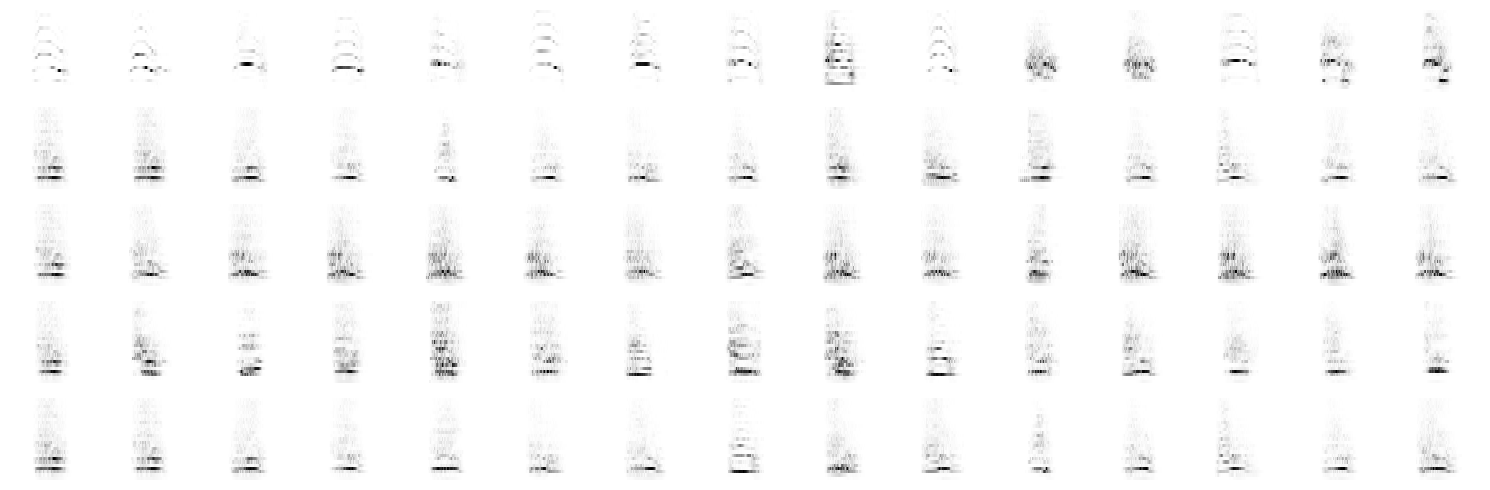

In [10]:
display_nearest_neighbours(nn_results_paf, calls_df)

In [23]:
_, _, labels_HDBSCAN_paf = silhouette_analysis_hdbscan(paf_scaled, embeddings=embeddings_paf, plot_best_clustering=True)

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


For min_cluster_size=66, min_samples=1, n_clusters=2:                 average silhouette_score=0.4183240490222866


/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


For min_cluster_size=66, min_samples=2, n_clusters=2:                 average silhouette_score=0.41123687442618206


/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


For min_cluster_size=66, min_samples=5, n_clusters=2:                 average silhouette_score=0.38898293552250496


/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


For min_cluster_size=66, min_samples=15, n_clusters=2:                 average silhouette_score=0.3973957905209517


/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/lena/Desktop/Master/Thesis/geese/code/GooseVocalizations/.venv/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


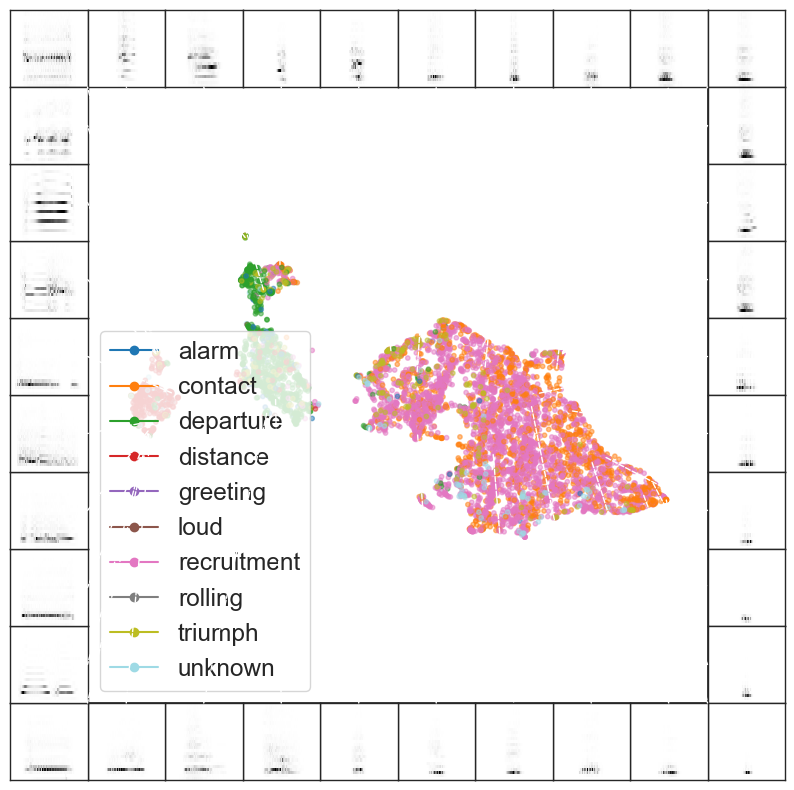

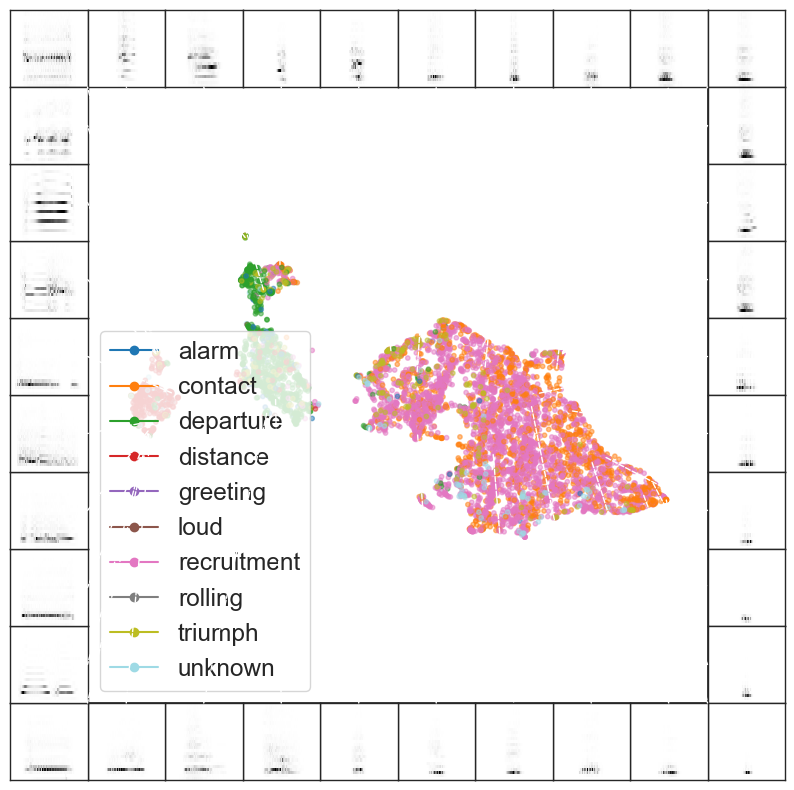

In [30]:
scatter_spec(embeddings_paf, calls_df["log_padded_spectrogram"], scatter_kwargs={"alpha": 0.5, "s": 10, "labels": calls_df["Call Type"]})